<a href="https://colab.research.google.com/github/b00001/sciusproject-hyperthermia/blob/main/week1_and_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rosensweig 2002, JMMM 252:370 https://ui.adsabs.harvard.edu/abs/2002JMMM..252..370R/abstract

| Magnetic solid | Chemical formula | Ms (kA m−1) | K (kJ m−3) | c (J kg−1 K−1) | ρ (kg m−3) |
|---|---|---|---|---|---|
| Maghemite | γ-Fe2O3 | 414 | −4.6 | ∼746 | 4600 |
| Magnetite | FeO·Fe2O3 | 446 | 23–41 | 670 | 5180 |
| Cobalt ferrite | CoO·Fe2O3 | 425 | 180–200 | 700 | 4907 |
| Barium ferrite | BaO·6Fe2O3 | 380 | 300–330 | ∼650 | 5280 |


In [178]:
#USE ONLY THE UNITS SPECIFIED IN THE COMMENTS AFTER EACH VALUE IN THIS CELL

Ms_in = 446e3            # [A/m]
K_in = 32e3               # [J/m^3]
Cp_in = 670                # [J/(kg K)]
rho_in = 5180              # [kg/m^3]

In [179]:
import numpy as np
import matplotlib.pyplot as plt

# ===========INPUT===========

In [180]:
def get_val(var):
    if isinstance(var, list) and len(var) == 3:
        return np.arange(var[0], var[2] + (var[1]/2), var[1])
    return np.array(var, dtype=float)

kB_in = 1.380649e-23        # [J/K]
mu0_in = 4 * np.pi * 1e-7   # [H/m]
tau0_in = 1e-9              # [s]

H_app_in = 0.1e-3             # [Tesla]
eta_in = 0.0015             # [Pa s]
T_in = [300, 10, 500]                  # [K]
f_in = 300e3              # [Hz]
delta_in = 0.1e-9           # [m]
R_in = 10e-9           # [m]

kB = get_val(kB_in)
mu0 = get_val(mu0_in)
tau0 = get_val(tau0_in)
rho = get_val(rho_in)
Cp = get_val(Cp_in)
Ms = get_val(Ms_in)
K = get_val(K_in)
eta = get_val(eta_in)
T = get_val(T_in)
f = get_val(f_in)
delta = get_val(delta_in)
R = get_val(R_in)

H_app = get_val(H_app_in) / mu0                  # tesla เป็น [A/m]
omega = 2 * np.pi * f                        # [rad/s]

In [181]:
VM = (4/3) * np.pi * (R**3)
VH = VM * ((1 + (delta / R))**3)
print(f"VM: {VM}")
print(f"VH: {VH}")

VM: 4.188790204786391e-24
VH: 4.315714736781624e-24


In [182]:
# Calculate xi (ξ) using the formula: μ₀MsVH₀/(k_BT)
# H_app is already in A/m
xi = (mu0 * Ms * VH * H_app) / (kB * T)

if isinstance(xi, np.ndarray) and xi.size > 1:
    print(f"Calculated xi (ξ) range: [{xi.min():.2e}, {xi.max():.2e}]")
else:
    print(f"Calculated xi (ξ): {xi:.2e}")

# Check if all xi values are less than or equal to 1
if np.all(xi <= 1):
    print("All values of xi are <= 1")
else:
    print("!!!!!!!!!!!Not all values of xi are <= 1!!!!!!!!!!!!!!!!!!!")

Calculated xi (ξ) range: [2.79e-02, 4.65e-02]
All values of xi are <= 1


# ===========TAU===========

In [183]:
# ===========TAU BROWNIAN CALCULATION===========
tau_b = (3 * eta * VH) / (kB * T)
print(f"tau_b: {tau_b}")
# ===========GAMMA CALCULATION===========
gamma = (K * VM) / (kB * T)
# ===========TAU NEEL CALCULATION===========
tau_n = (tau0/2) * np.exp(gamma)
print(f"tau_n: {tau_n}")

tau_b: [4.68878919e-06 4.53753792e-06 4.39573986e-06 4.26253563e-06
 4.13716693e-06 4.01896216e-06 3.90732432e-06 3.80172096e-06
 3.70167568e-06 3.60676091e-06 3.51659189e-06 3.43082136e-06
 3.34913514e-06 3.27124827e-06 3.19690172e-06 3.12585946e-06
 3.05790599e-06 2.99284416e-06 2.93049324e-06 2.87068726e-06
 2.81327351e-06]
tau_n: [5.66977533e+04 1.99614364e+04 7.50159493e+03 2.99140571e+03
 1.25916889e+03 5.56886184e+02 2.57711150e+02 1.24333528e+02
 6.23309242e+01 3.23740906e+01 1.73746829e+01 9.61215184e+00
 5.46974445e+00 3.19522900e+00 1.91270939e+00 1.17138745e+00
 7.32842712e-01 4.67722895e-01 3.04153212e-01 2.01291114e-01
 1.35433940e-01]


In [184]:
# ===========EFFECTIVE RELAXATION TIME CALCULATION===========
tau_eff = 1 / ((1 / tau_b) + (1 / tau_n))
print(f"tau_eff: {tau_eff}")

tau_eff: [4.68878919e-06 4.53753792e-06 4.39573986e-06 4.26253562e-06
 4.13716692e-06 4.01896213e-06 3.90732427e-06 3.80172085e-06
 3.70167546e-06 3.60676051e-06 3.51659118e-06 3.43082013e-06
 3.34913308e-06 3.27124492e-06 3.19689638e-06 3.12585112e-06
 3.05789323e-06 2.99282501e-06 2.93046501e-06 2.87064632e-06
 2.81321508e-06]


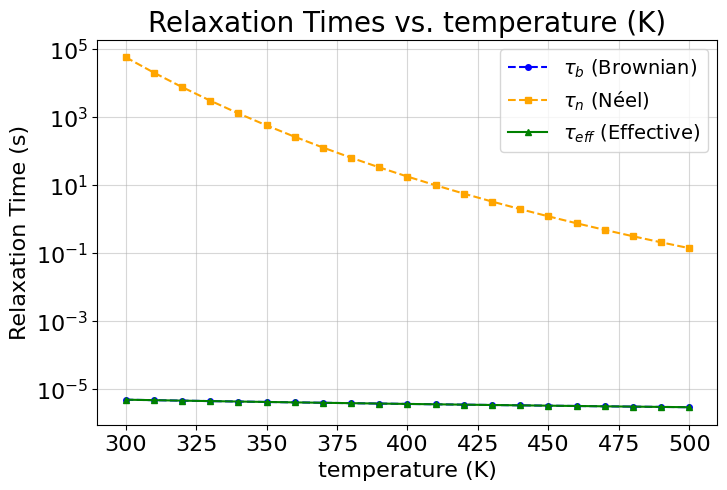

In [185]:
import matplotlib.pyplot as plt

# =========== PLOT RELAXATION TIMES VS Radius ===========

plt.figure(figsize=(8, 5))

# ใช้ตัวแปรอาเรย์ที่คำนวณไว้แล้ว (R, tau_b, tau_n, tau_eff) เพื่อพล็อตเป็นเส้นตามช่วงรัศมี
plt.plot(T, tau_b, label=r'$\tau_b$ (Brownian)', linestyle='--', marker='o', color='blue', markersize=4)
plt.plot(T, tau_n, label=r'$\tau_n$ (Néel)', linestyle='--', marker='s', color='orange', markersize=4)
plt.plot(T, tau_eff, label=r'$\tau_{eff}$ (Effective)', linestyle='-', marker='^', color='green', markersize=4)

plt.xlabel('temperature (K)', fontsize=16)
plt.ylabel('Relaxation Time (s)', fontsize=16)
plt.title('Relaxation Times vs. temperature (K)', fontsize=20)
plt.yscale('log')
plt.legend(fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.tick_params(axis='both', labelsize=16)
plt.show()

# ===========SUSCEPTIBILITBY===========

In [186]:
import matplotlib.pyplot as plt
import numpy as np

chi0 = (mu0 * (Ms ** 2) * VM) / (3 * kB * T)
chi_prime = chi0 / (1 + (omega * tau_eff) ** 2)
chi_doubleprime = (chi0 * omega * tau_eff) / (1 + (omega * tau_eff) ** 2)

print(f"chi0 : {chi0}")
print(f"chi_prime : {chi_prime}")
print(f"chi_doubleprime : {chi_doubleprime}")


chi0 : [84.26406353 81.54586794 78.99755956 76.60369412 74.3506443  72.22634017
 70.22005295 68.32221368 66.52426069 64.81851041 63.19804765 61.65663185
 60.18861681 58.78888154 57.45277059 56.17604236 54.95482404 53.78557247
 52.66503971 51.59024298 50.55843812]
chi_prime : [1.06510937 1.09967091 1.13414153 1.16851857 1.2027994  1.23698143
 1.27106207 1.30503879 1.33890908 1.37267047 1.40632055 1.43985695
 1.47327737 1.50657964 1.53976165 1.5728215  1.60575744 1.638568
 1.67125202 1.70380873 1.73623789]
chi_doubleprime : [9.41360643 9.4055485  9.39724086 9.38868484 9.37988187 9.37083338
 9.36154085 9.35200583 9.34222989 9.3322147  9.321962   9.31147365
 9.30075164 9.28979814 9.27861558 9.26720668 9.25557458 9.2437229
 9.2316559  9.21937863 9.20689708]


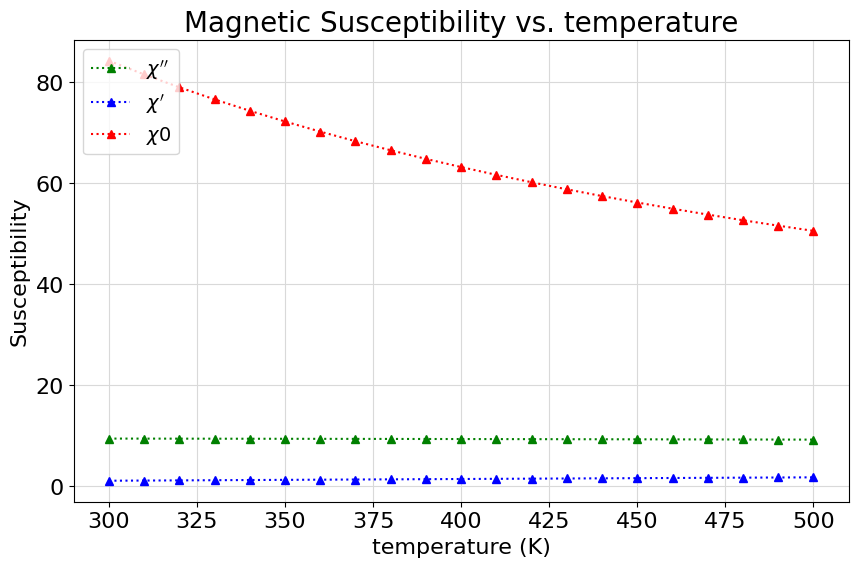

In [187]:
plt.figure(figsize=(10, 6))
# ใช้ค่าอาเรย์ที่คำนวณไว้ (R, chi_doubleprime) สำหรับวัสดุ Barium ferrite
plt.plot(T, chi_doubleprime, label=r"$\chi''$", marker='^', linestyle=':', color='green')
plt.plot(T, chi_prime, label=r"$\chi'$", marker='^', linestyle=':', color='blue')
plt.plot(T, chi0, label=r"$\chi0$", marker='^', linestyle=':', color='red')

plt.xlabel('temperature (K)', fontsize=16)
plt.ylabel('Susceptibility', fontsize=16)
plt.title('Magnetic Susceptibility vs. temperature', fontsize=20)
plt.legend(loc='upper left', fontsize=14)
plt.grid(True, which="both", ls="-", color='0.85')
plt.tick_params(axis='both', labelsize=16)
plt.show()

# ===========POWER DISSIPATION===========

---



In [188]:
#POWER DISSIPATION
P = mu0 * H_app ** 2 * f * np.pi * chi_doubleprime
print(f"Power dissiption: {P}")
#Heating rate
T_s = P / (rho * Cp)
print(f"Heating rate: {T_s}")
SAR = P / rho   # [W/m³] / [kg/m³] = [W/kg]
print(f"SAR: {SAR} W/kg")

Power dissiption: [70602.04821373 70541.61378053 70479.30641498 70415.13633016
 70349.11403396 70281.2503404  70211.55639091 70140.04369086
 70066.72416754 69991.61025805 69914.7150371  69836.05239642
 69755.63728912 69673.4860535  69589.61683156 69504.05009769
 69416.80931252 69327.92171567 69237.41926937 69145.33976221
 69051.72807908]
Heating rate: [0.02034289 0.02032548 0.02030753 0.02028904 0.02027001 0.02025046
 0.02023038 0.02020977 0.02018865 0.02016701 0.02014485 0.02012218
 0.02009901 0.02007534 0.02005118 0.02002652 0.02000139 0.01997577
 0.0199497  0.01992317 0.01989619]
SAR: [13.62973904 13.61807216 13.60604371 13.59365566 13.58091005 13.56780895
 13.55435452 13.54054898 13.52639463 13.51189387 13.49704923 13.4818634
 13.46633925 13.45047993 13.43428896 13.41777029 13.40092844 13.38376867
 13.36629716 13.34852119 13.33044944] W/kg


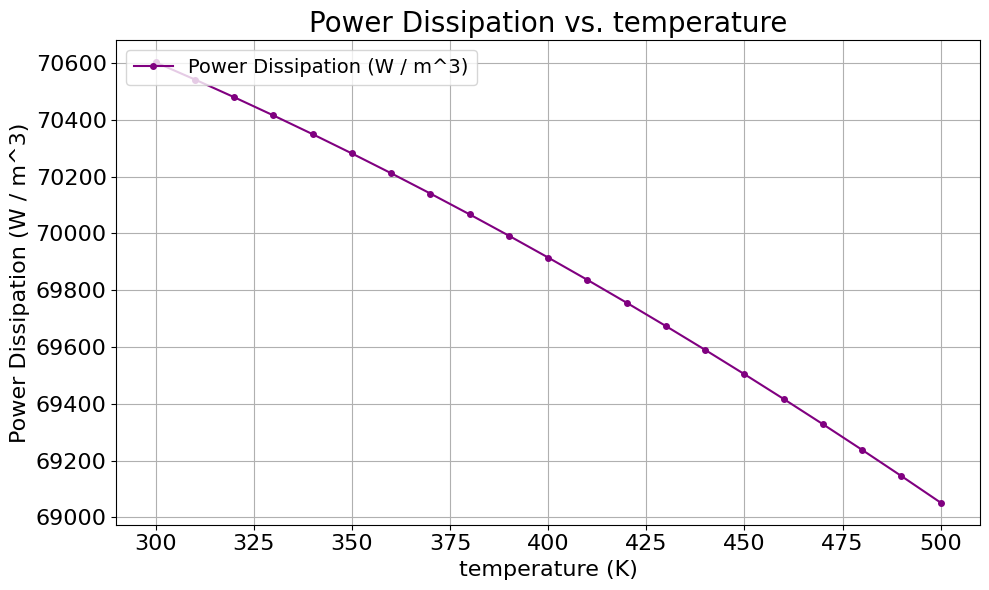

In [189]:
plt.figure(figsize=(10, 6))

plt.plot(T, P, marker='o', linestyle='-', color='purple', label='Power Dissipation (W / m^3)', markersize=4)

plt.ylabel('Power Dissipation (W / m^3)', fontsize=16)
plt.title('Power Dissipation vs. temperature', fontsize=20)
plt.grid(True)
plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', labelsize=16)
plt.xlabel('temperature (K)', fontsize=16)
plt.tight_layout()
plt.show()

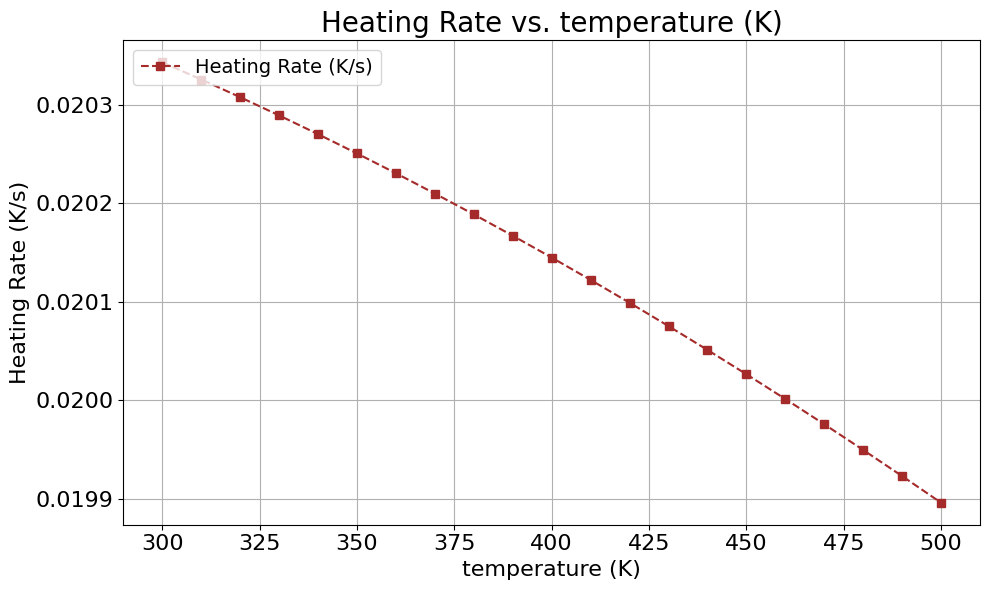

In [190]:
plt.figure(figsize=(10, 6))
plt.plot(T, T_s, marker='s', linestyle='--', color='brown', label='Heating Rate (K/s)')
plt.ylabel('Heating Rate (K/s)', fontsize=16)
plt.title('Heating Rate vs. temperature (K)', fontsize=20)
plt.grid(True)
plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', labelsize=16)
plt.xlabel('temperature (K)', fontsize=16)
plt.tight_layout()
plt.show()

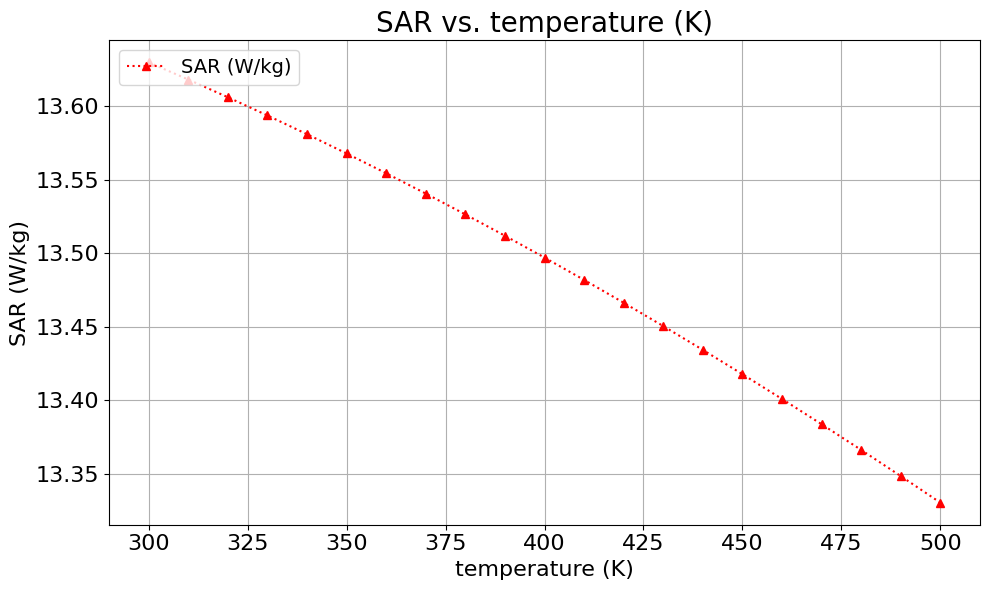

In [191]:
# Plot SAR vs Radius
plt.figure(figsize=(10, 6))
# ใช้ค่าอาเรย์ SAR และ R ที่คำนวณไว้แล้ว
plt.plot(T, SAR, marker='^', linestyle=':', color='red', label='SAR (W/kg)')
plt.xlabel('temperature (K)', fontsize=16)
plt.ylabel('SAR (W/kg)', fontsize=16)
plt.title('SAR vs. temperature (K)', fontsize=20)
plt.grid(True)
plt.legend(loc='upper left', fontsize=14)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

### Magnetic relaxation time  ($\\tau$) vs. Radius for Different Materials

In [192]:
import matplotlib.pyplot as plt
import numpy as np

def get_val(var):
    if isinstance(var, list) and len(var) == 3:
        return np.arange(var[0], var[2] + (var[1]/2), var[1])
    return np.array(var, dtype=float)

# ---- ค่าคงที่และเงื่อนไขที่ใช้ร่วมกัน ----
mu0_c   = 4 * np.pi * 1e-7      # [H/m]
kB_c    = 1.380649e-23          # [J/K]
tau0_c  = 1e-9                  # [s]
T_c     = 300                   # [K]
f_c     = 300e3                 # [Hz]
eta_c   = 0.0015                # [Pa s]
delta_c = 0.1e-9                # [m]
H_app_c = 0.1e-3 / mu0_c        # 0.1 mT -> [A/m]
omega_c = 2 * np.pi * f_c

R_plot  = get_val([0.2e-9, 0.2e-9, 8e-9])
VM_plot = (4/3) * np.pi * (R_plot**3)
VH_plot = VM_plot * ((1 + (delta_c / R_plot))**3)

materials_data = {
    'Maghemite': {'Ms': 414e3, 'K': -4.6e3, 'Cp': 746, 'rho': 4600},
    'Magnetite': {'Ms': 446e3, 'K': 32e3, 'Cp': 670, 'rho': 5180},
    'Cobalt ferrite': {'Ms': 425e3, 'K': 190e3, 'Cp': 700, 'rho': 4907},
    'Barium ferrite': {'Ms': 380e3, 'K': 315e3, 'Cp': 650, 'rho': 5280}
}

colors = {
    'Maghemite': 'blue',
    'Magnetite': 'green',
    'Cobalt ferrite': 'red',
    'Barium ferrite': 'orange'
}

chi_doubleprime_all = {}
P_all = {}
SAR_all = {}
HeatingRate_all = {}


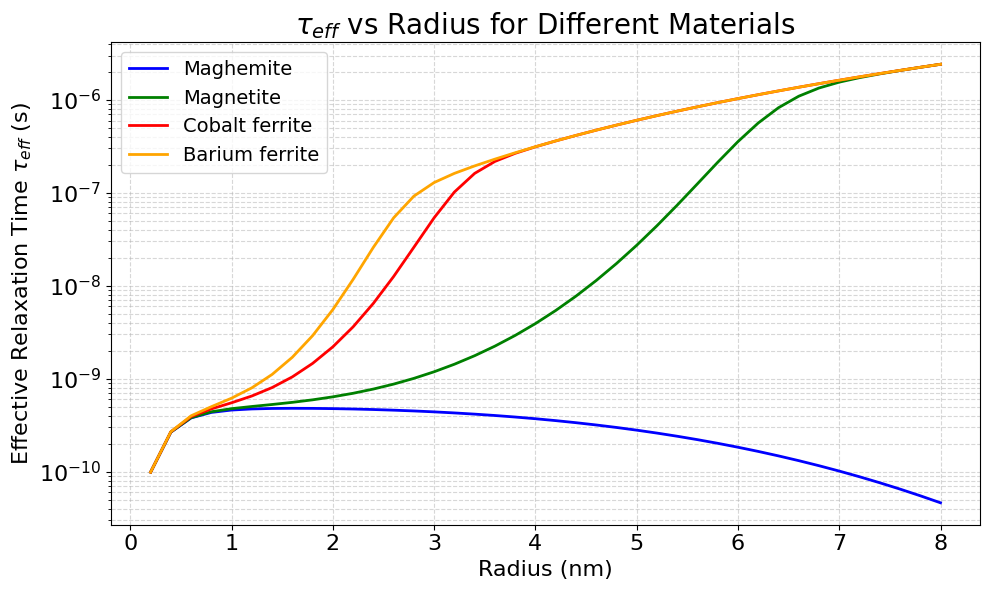

In [193]:
plt.figure(figsize=(10, 6))

# Loop through each material and plot tau_eff vs. Radius
for name, props in materials_data.items():
    current_Ms  = props['Ms']
    current_K   = props['K']

    tau_b_plot = (3 * eta_c * VH_plot) / (kB_c * T_c)
    gamma_plot   = (current_K * VM_plot) / (kB_c * T_c)
    tau_n_plot   = (tau0_c/2) * np.exp(gamma_plot)
    tau_eff_plot = 1 / ((1 / tau_b_plot) + (1 / tau_n_plot))

    plt.plot(R_plot * 1e9, tau_eff_plot, label=name, color=colors[name], linewidth=2)

plt.xlabel('Radius (nm)', fontsize=16)
plt.ylabel(r"Effective Relaxation Time $\tau_{eff}$ (s)", fontsize=16)
plt.title(r"$\tau_{eff}$ vs Radius for Different Materials", fontsize=20)
plt.legend(fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.yscale('log') # Use logarithmic scale for y-axis
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

### Effective Relaxation Time ($\chi$) vs. Radius for Different Materials

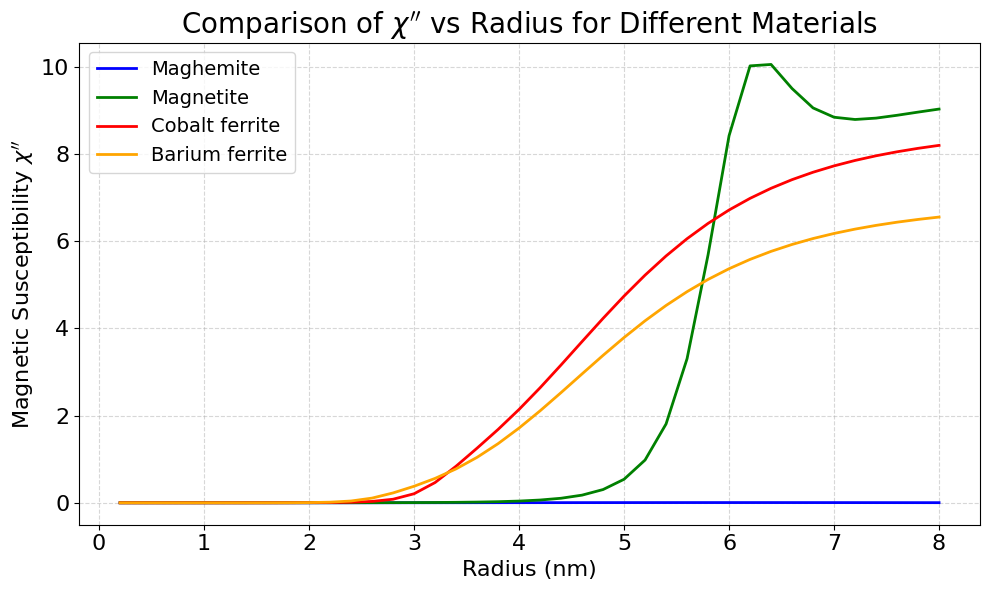

In [194]:
for name, props in materials_data.items():
    current_Ms  = props['Ms']
    current_K   = props['K']
    current_rho = props['rho']
    current_Cp  = props['Cp']

    tau_b_plot = (3 * eta_c * VH_plot) / (kB_c * T_c)
    gamma_plot   = (current_K * VM_plot) / (kB_c * T_c)
    tau_n_plot   = (tau0_c/2) * np.exp(gamma_plot)
    tau_eff_plot = 1 / ((1 / tau_b_plot) + (1 / tau_n_plot))

    chi0_plot = (mu0_c * (current_Ms ** 2) * VM_plot) / (3 * kB_c * T_c)
    chi_doubleprime_plot = (chi0_plot * omega_c * tau_eff_plot) / (1 + (omega_c * tau_eff_plot) ** 2)

    # ---- power dissipation, SAR, heating rate ----
    P_plot = mu0_c * H_app_c ** 2 * f_c * np.pi * chi_doubleprime_plot

    chi_doubleprime_all[name] = chi_doubleprime_plot
    P_all[name]               = P_plot
    SAR_all[name]             = P_plot / current_rho
    HeatingRate_all[name]     = P_plot / (current_rho * current_Cp)

plt.figure(figsize=(10, 6))
for name, chi_dd in chi_doubleprime_all.items():
    plt.plot(R_plot * 1e9, chi_dd, label=name, color=colors[name], linewidth=2)

plt.xlabel('Radius (nm)', fontsize=16)
plt.ylabel(r"Magnetic Susceptibility $\chi''$", fontsize=16)
plt.title(r"Comparison of $\chi''$ vs Radius for Different Materials", fontsize=20)
plt.legend(fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

### Comparison of P, SAR, and Heating Rate for Different Materials
We will now use the previously calculated data to plot the heating characteristics across different material types.

### Individual Plots for Each Material Characteristic

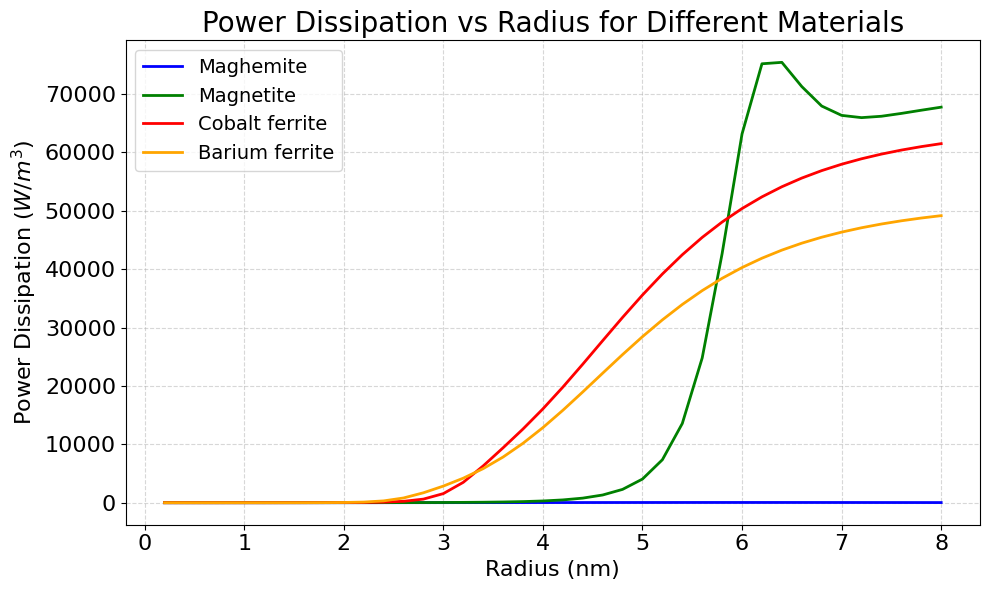

In [195]:
# 1. Individual Power Dissipation Plot
plt.figure(figsize=(10, 6))
for name in materials_data:
    plt.plot(R_plot * 1e9, P_all[name], label=name, color=colors[name], linewidth=2)
plt.xlabel('Radius (nm)', fontsize=16)
plt.ylabel('Power Dissipation ($W/m^3$)', fontsize=16)
plt.title('Power Dissipation vs Radius for Different Materials', fontsize=20)
plt.legend(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

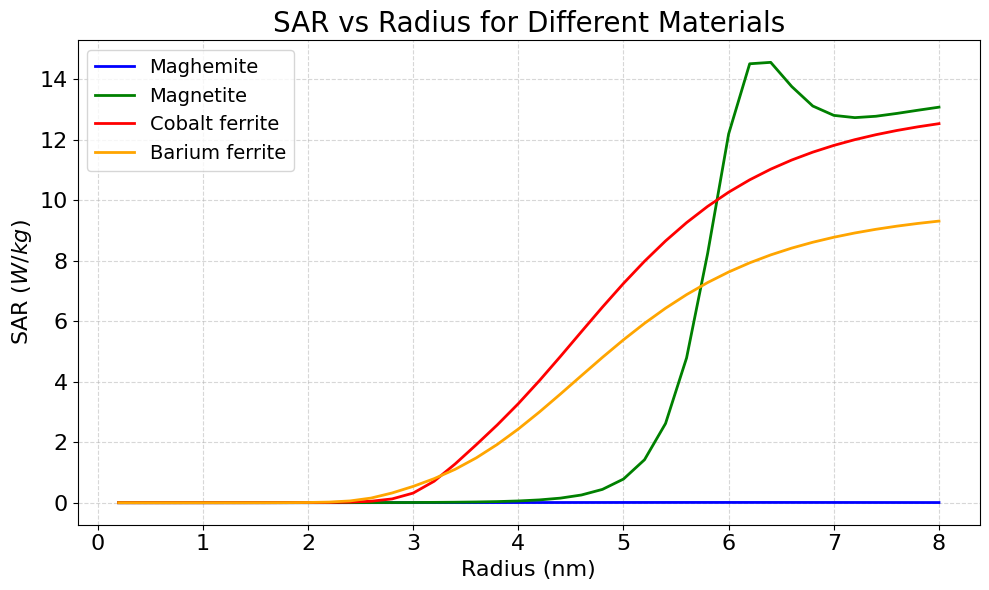

In [196]:
# 2. Individual SAR Plot
plt.figure(figsize=(10, 6))
for name in materials_data:
    plt.plot(R_plot * 1e9, SAR_all[name], label=name, color=colors[name], linewidth=2)
plt.xlabel('Radius (nm)', fontsize=16)
plt.ylabel('SAR ($W/kg$)', fontsize=16)
plt.title('SAR vs Radius for Different Materials', fontsize=20)
plt.legend(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

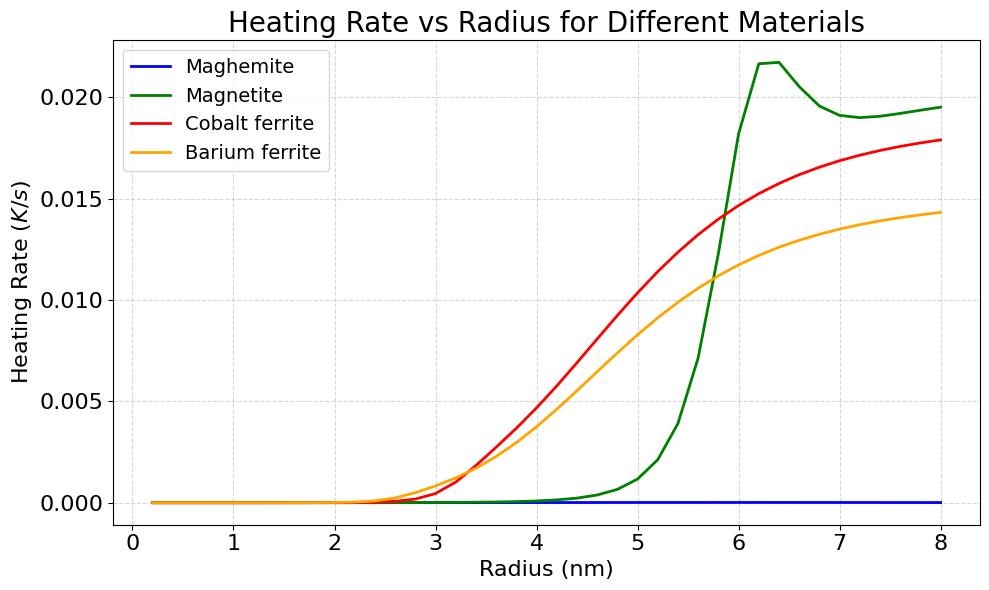

In [197]:
# 3. Individual Heating Rate Plot
plt.figure(figsize=(10, 6))
for name in materials_data:
    plt.plot(R_plot * 1e9, HeatingRate_all[name], label=name, color=colors[name], linewidth=2)
plt.xlabel('Radius (nm)', fontsize=16)
plt.ylabel('Heating Rate ($K/s$)', fontsize=16)
plt.title('Heating Rate vs Radius for Different Materials', fontsize=20)
plt.legend(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

==================================================================
 Nanoparticle Temperature vs Time (Magnetic Hyperthermia, LRT)
==================================================================

Validity check: LRT applies when xi = (mu0 * Ms * V_H * H0) / (kB * T) <= 1

HOW IT WORKS
------------
Fixed inputs: viscosity (eta), frequency (f), core radius (R),
              shell thickness (delta)

Field: H(t) amplitude is defined as a function of time

Procedure:
  1. Set initial temperature T_initial
  2. Loop over each time step (n_steps = t_total / dt):
       - compute H(t)
       - compute relaxation times (tau_B, tau_N, tau_eff)
       - compute chi0 and chi'' (out-of-phase susceptibility)
       - compute power dissipation P
       - compute heating rate and update temperature
       - store H(t), heating rate, temperature, and xi
  3. Stop if xi >= 1 (outside the linear response regime)


In [198]:
dt        = 1e-2      # [s]  time step
t_total   = 200       # [s]  เวลารวม
n_steps   = int(t_total / dt)
T_initial = 300.0     # [K]

# ================================================================
# ================================================================
eta   = 0.0015        # [Pa s]
f     = 300e3         # [Hz]
delta = 1e-9          # [m]
R     = 6e-9          # [m]

omega = 2 * np.pi * f
VM = (4.0 / 3.0) * np.pi * R ** 3
VH = (4.0 / 3.0) * np.pi * (R + delta) ** 3

# ================================================================
#  H_A(t) : amplitude ของสนาม [Tesla] เป็นฟังก์ชันของเวลา
#  >>> แก้สูตรตรงนี้ทีเดียว <<<
# ================================================================
H_max = 1e-3      # [T] ค่าช่วงแรก (ที่ราบสูง)
H_min = 0e-3    # [T] ค่าหลังดิ่งลง (ที่ราบต่ำ)
t0    = 40.0      # [s] จุดกึ่งกลางที่ดิ่งลง
w     = 0.8       # [s] ความชัน (เล็ก = ดิ่งชันขึ้น)

H_of_t = lambda t: H_min + (H_max - H_min) / (1 + np.exp((t - t0) / w))


In [199]:
time_array = np.zeros(n_steps + 1)
Temp_array = np.zeros(n_steps + 1)
P_array    = np.zeros(n_steps + 1)
xi_array   = np.zeros(n_steps + 1)
H_array    = np.zeros(n_steps + 1)

Temp_array[0] = T_initial
H_array[0]    = H_of_t(0.0)
xi_array[0]   = (mu0 * Ms * VH * (H_array[0] / mu0)) / (kB * T_initial)

tem_i  = T_initial
last_i = n_steps

# ================================================================
#  LOOP
# ================================================================
for i in range(1, n_steps + 1):

    t   = i * dt
    H_T = H_of_t(t)          # amplitude [Tesla] ณ เวลา t
    H_A = H_T / mu0          # Tesla -> A/m

    # ---- relaxation times ----
    gamma   = (K * VM) / (kB * tem_i)
    tau_b   = (3 * eta * VH) / (kB * tem_i)
    tau_n   = (tau0 / 2) * np.exp(gamma)
    tau_eff = 1 / ((1 / tau_b) + (1 / tau_n))

    # ---- susceptibility & power ----
    chi0 = (mu0 * Ms ** 2 * VM) / (3 * kB * tem_i)
    chi_doubleprime = (chi0 * omega * tau_eff) / (1 + (omega * tau_eff) ** 2)
    P = mu0 * H_A ** 2 * f * np.pi * chi_doubleprime

    # ---- update temperature ----
    tem_i = tem_i + (P / (rho * Cp)) * dt

    # ---- เก็บผลลัพธ์ ----
    time_array[i] = t
    Temp_array[i] = tem_i
    P_array[i]    = P
    H_array[i]    = H_T

    # ---- ตรวจเงื่อนไข LRT (xi << 1) ----
    xi = (mu0 * Ms * VH * H_A) / (kB * tem_i)
    xi_array[i] = xi
    if xi >= 1:
        print(f"ไม่ได้: xi = {xi:.3f} >= 1 ที่ t = {t:.2f} s")
        print(f"อุณหภูมิล่าสุด = {tem_i:.4f} K")
        last_i = i
        break


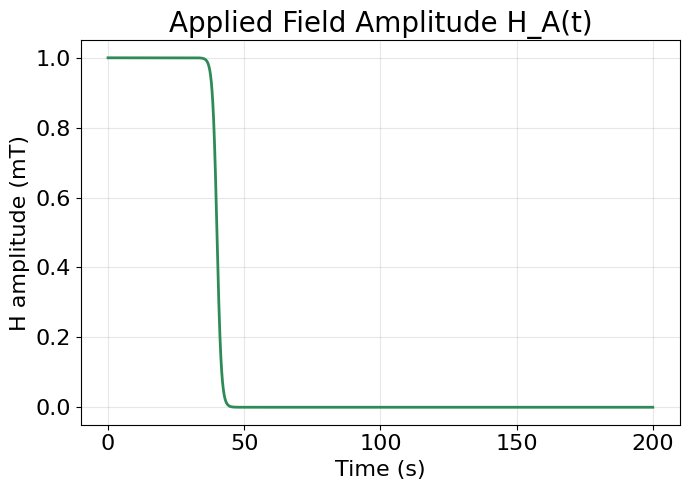

In [200]:
# ================================================================
#  PLOT
# ================================================================
sl = slice(None)
# ---- H(t) ----
plt.figure(figsize=(7, 5))
plt.plot(time_array[sl], H_array[sl] * 1e3, color='seagreen', linewidth=2)
plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('H amplitude (mT)', fontsize=16)
plt.title('Applied Field Amplitude H_A(t)', fontsize=20)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()

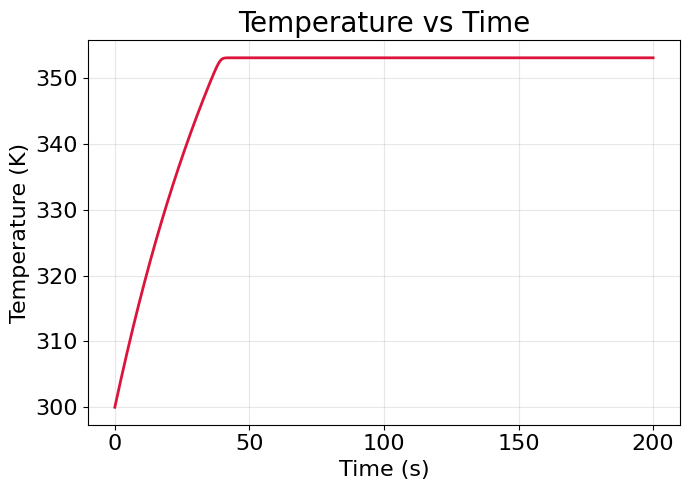

อุณหภูมิสุดท้ายที่ t = 200.00 s: 353.1358 K


In [201]:
# ---- Temperature vs Time ----
plt.figure(figsize=(7, 5))
plt.plot(time_array[sl], Temp_array[sl], color='crimson', linewidth=2)
plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('Temperature (K)', fontsize=16)
plt.title('Temperature vs Time', fontsize=20)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()
print(f"อุณหภูมิสุดท้ายที่ t = {time_array[last_i]:.2f} s: {Temp_array[last_i]:.4f} K")

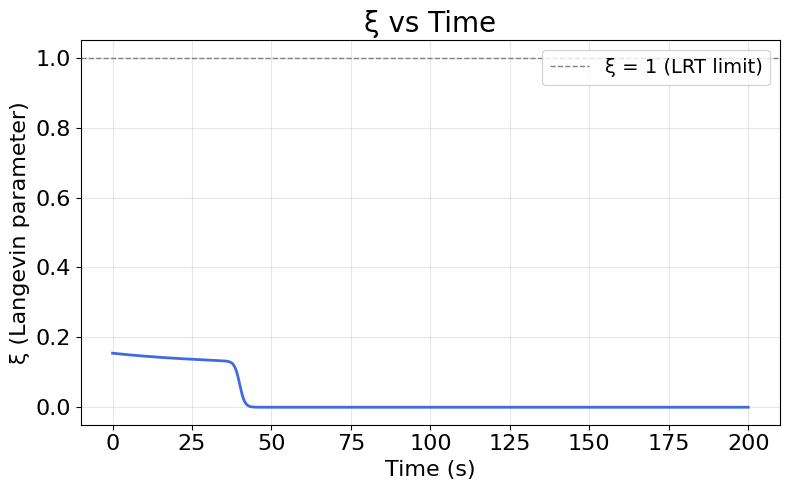

In [202]:
# ---- xi vs Time ----
plt.figure(figsize=(8, 5))
plt.plot(time_array[sl], xi_array[sl], color='royalblue', linewidth=2)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=1, label='ξ = 1 (LRT limit)')
plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('ξ (Langevin parameter)', fontsize=16)
plt.title('ξ vs Time', fontsize=20)
plt.legend(loc='upper right', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.show()